# Model Development for Ames Housing

This notebook covers:
1. Training multiple models
2. Hyperparameter tuning
3. Model comparison
4. Saving the best model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import json

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [2]:
# Load processed data
df = pd.read_csv('../data/processed/ames_processed.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (2930, 51)


,Order,MS SubClass,Lot Frontage,Lot Area,Neighborhood,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Exterior 1st,...,Bedroom_Per_Room,Bathroom_Per_Room,Total_Porch_SF,Has_Fireplace,Garage_Cars_Per_Area,Quality_Score,Quality_Per_Room,Neighborhood_Price_Level,Neighborhood_Price_Level_Rank,SalePrice
0,-1.736230,-1.116308,2.379115,2.518337,0.090340,-0.046404,-0.526415,-0.346360,-1.151179,-1.960930,...,-0.114173,-0.483684,0.704712,0.976388,0.046911,-0.406311,-0.426354,-0.576215,-0.388516,215000
1,-1.735043,-1.116308,0.607300,0.531450,0.090340,-0.766750,0.378216,-0.313395,-1.103060,0.780255,...,-0.616586,-1.279725,0.653915,-1.024183,-1.854896,-0.406311,-0.028402,-0.576215,-0.388516,105000
2,-1.733857,-1.116308,0.646026,0.936573,0.090340,-0.046404,0.378216,-0.412291,-1.247417,1.054374,...,0.531787,-0.824845,1.276069,-1.024183,-0.511965,0.251343,0.085298,-0.576215,-0.388516,172000
3,-1.732670,-1.116308,1.077085,0.451308,0.090340,0.673941,-0.526415,-0.082638,-0.766228,-1.960930,...,-0.616586,0.843050,-1.743130,0.976388,0.091059,0.141734,-0.293703,-0.576215,-0.388516,244000
4,-1.731484,0.416550,0.364396,0.875109,-0.893922,-0.766750,-0.526415,0.873354,0.677339,0.780255,...,0.531787,0.539797,0.592917,0.976388,0.425484,-0.954356,-0.596904,0.311075,0.445912,189900


In [3]:
# Prepare features and target
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

Training set: (2344, 50)
Test set: (586, 50)


## Define Models

In [4]:
def get_models():
    """Return dictionary of models to evaluate."""
    return {
        'Linear Regression': LinearRegression(),
        'Ridge': Ridge(random_state=42),
        'Lasso': Lasso(random_state=42),
        'ElasticNet': ElasticNet(random_state=42),
        'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42),
        'XGBoost': XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        'CatBoost': CatBoostRegressor(random_state=42, verbose=0),
        'SVR': SVR()
    }

## Train and Evaluate Models

In [5]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    """Train and evaluate a single model."""
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, 
                                scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)
    
    metrics = {
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'train_mae': mean_absolute_error(y_train, y_pred_train),
        'test_mae': mean_absolute_error(y_test, y_pred_test),
        'train_r2': r2_score(y_train, y_pred_train),
        'test_r2': r2_score(y_test, y_pred_test),
        'cv_rmse_mean': cv_rmse.mean(),
        'cv_rmse_std': cv_rmse.std()
    }
    
    return metrics, model


# Train all models
models = get_models()
results = []
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...')
    try:
        metrics, trained_model = evaluate_model(model, X_train, y_train, X_test, y_test)
        metrics['model'] = name
        results.append(metrics)
        trained_models[name] = trained_model
        print(f'  Test RMSE: {metrics["test_rmse"]:.2f}, R²: {metrics["test_r2"]:.4f}')
    except Exception as e:
        print(f'  Error: {e}')

# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_rmse')
results_df

Training Linear Regression...
  Test RMSE: 34525.04, R²: 0.8513
Training Ridge...
  Test RMSE: 34438.46, R²: 0.8521
Training Lasso...
  Test RMSE: 34549.27, R²: 0.8511
Training ElasticNet...
  Test RMSE: 35774.35, R²: 0.8404
Training Random Forest...
  Test RMSE: 24571.00, R²: 0.9247
Training Gradient Boosting...
  Test RMSE: 23013.60, R²: 0.9339
Training XGBoost...
  Test RMSE: 24940.07, R²: 0.9224
Training LightGBM...
  Test RMSE: 24509.74, R²: 0.9251
Training CatBoost...
  Test RMSE: 20370.78, R²: 0.9482
Training SVR...
  Test RMSE: 94204.31, R²: -0.1069


,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2,cv_rmse_mean,cv_rmse_std,model
8,7391.076748,20370.778761,5624.238626,12631.045754,0.990812,0.948242,21257.522073,1356.224637,CatBoost
5,15412.129911,23013.604312,11217.745140,14496.527662,0.960050,0.933942,23150.702872,1676.533618,Gradient Boosting
7,10615.678971,24509.742567,6859.277271,13976.712754,0.981046,0.925073,24349.255848,1281.264979,LightGBM
4,9596.136900,24570.997117,5805.751975,14456.645119,0.984512,0.924698,24868.676410,2091.059248,Random Forest
6,2293.156667,24940.074098,1655.398193,15049.331055,0.999116,0.922419,25696.043659,1930.190325,XGBoost
1,28303.570919,34438.464472,18520.023696,20798.092171,0.865266,0.852073,29888.990573,2973.361323,Ridge
0,28300.322692,34525.036726,18543.343194,20847.324614,0.865297,0.851329,29978.072533,2973.036476,Linear Regression
2,28300.786108,34549.270668,18548.516427,20857.624759,0.865293,0.851120,29959.744368,2965.687045,Lasso
3,31092.360058,35774.347835,19589.107954,20772.151501,0.837407,0.840375,31464.196003,2303.101960,ElasticNet
9,79203.583006,94204.310414,53978.589505,63697.077046,-0.055076,-0.106879,79190.118763,2955.925302,SVR


## Visualize Results

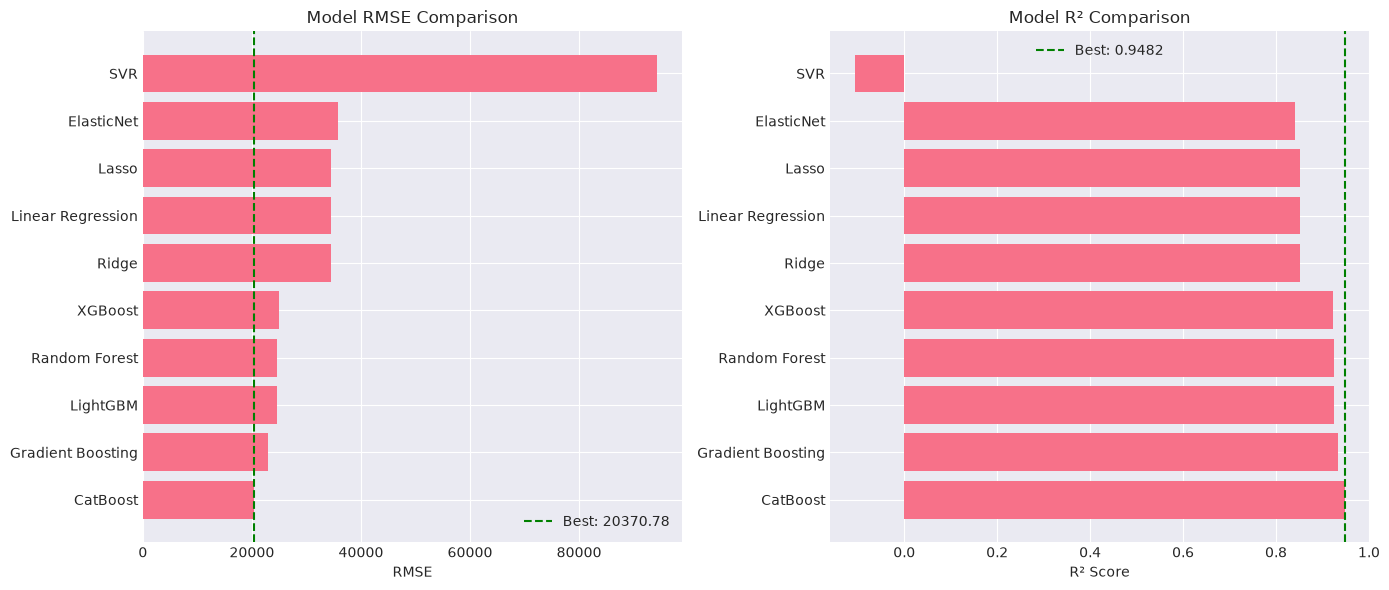

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RMSE comparison
axes[0].barh(results_df['model'], results_df['test_rmse'])
axes[0].set_title('Model RMSE Comparison')
axes[0].set_xlabel('RMSE')
axes[0].axvline(results_df['test_rmse'].min(), color='green', linestyle='--', 
                label=f'Best: {results_df["test_rmse"].min():.2f}')
axes[0].legend()

# R² comparison
axes[1].barh(results_df['model'], results_df['test_r2'])
axes[1].set_title('Model R² Comparison')
axes[1].set_xlabel('R² Score')
axes[1].axvline(results_df['test_r2'].max(), color='green', linestyle='--', 
                label=f'Best: {results_df["test_r2"].max():.4f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Hyperparameter Tuning - Best Model

In [7]:
# Get best model type
best_model_name = results_df.iloc[0]['model']
print(f'Best model: {best_model_name}')

# Define parameter grids for top models
param_grids = {
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'num_leaves': [31, 50, 80],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [5, 10, 15]
    },
    'CatBoost': {
        'iterations': [100, 200, 300],
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
}

# If best model is in param_grids, tune it
if best_model_name in param_grids:
    base_model = models[best_model_name]
    param_grid = param_grids[best_model_name]
    
    print(f'\nTuning {best_model_name}...')
    grid_search = GridSearchCV(
        base_model, param_grid, cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1, verbose=1
    )
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    print(f'Best parameters: {grid_search.best_params_}')
    print(f'Best CV score: {-grid_search.best_score_:.4f}')
else:
    # Use the best model from initial training
    best_model = trained_models[best_model_name]

# Evaluate tuned model
y_pred = best_model.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)
print(f'\nFinal Model Performance:')
print(f'RMSE: {final_rmse:.2f}')
print(f'R² Score: {final_r2:.4f}')

Best model: CatBoost

Tuning CatBoost...
Fitting 5 folds for each of 81 candidates, totalling 405 fits


Best parameters: {'depth': 6, 'iterations': 300, 'l2_leaf_reg': 5, 'learning_rate': 0.1}
Best CV score: 463122629.9096

Final Model Performance:
RMSE: 21443.97
R² Score: 0.9426


## Save Best Model

In [8]:
# Save model
joblib.dump(best_model, '../models/best_model.pkl')
print('Model saved to models/best_model.pkl')

# Save metrics
model_metrics = {
    'model_name': best_model_name,
    'test_rmse': float(final_rmse),
    'test_r2': float(final_r2),
    'train_size': len(X_train),
    'test_size': len(X_test),
    'n_features': X_train.shape[1],
    'best_params': grid_search.best_params_ if best_model_name in param_grids else {}
}

with open('../models/model_metrics.json', 'w') as f:
    json.dump(model_metrics, f, indent=2)
print('Metrics saved to models/model_metrics.json')

Model saved to models/best_model.pkl
Metrics saved to models/model_metrics.json
